## Qualitative comparison

In [1]:
import os
#virtually move to parent directory
os.chdir("..")

import torch
import pandas as pd

import matplotlib
from matplotlib import pyplot as plt

import utils
import data_utils
import similarity
from experiments import text_colorings

/home/umar/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
# Change this to select which figure is plotted
figure = 'tiny_vit'

settings = {'fig1a': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": [46, 10, 242, 206]}, 
            'fig1b': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": [1203, 1731, 683, 185]},
            'fig6a': {"target_name":'resnet18_places', "target_layer": 'layer4', "neurons_to_display": "NetDissect"},
            'fig6b': {"target_name":'resnet18_places', "target_layer": 'layer4', "neurons_to_display": "CLIP-Dissect"},
            'fig7a': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": "NetDissect"},
            'fig7b': {"target_name":'resnet50', "target_layer": 'layer4', "neurons_to_display": "CLIP-Dissect"},
            'fig9a': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": "NetDissect"},
            'fig9b': {"target_name":'resnet50', "target_layer": 'layer1', "neurons_to_display": "CLIP-Dissect"},
            'tiny_vit': {"target_name":'tiny_vit_21m_224', "target_layer": 'head', "neurons_to_display": "CLIP-Dissect"},
           }

target_name = settings[figure]["target_name"]
target_layer = settings[figure]["target_layer"]
neurons_to_display = settings[figure]["neurons_to_display"]

clip_name = 'ViT-B/16'
d_probe = 'imagenet_val'
concept_set = 'data/20k.txt'
batch_size = 200
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Run CLIP-Dissect

In [3]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

In [4]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn, device=device)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

100%|██████████| 1000/1000 [00:03<00:00, 314.98it/s]


torch.Size([1000, 20000])


## Visualize

In [5]:
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

get_color = text_colorings.get_coloring(figure)

name_conversion = {'resnet50':'resnet50_imagenet', 'resnet18_places':'resnet18_places365'}
ood_names = {'resnet50':'p', 'resnet18_places': 'i'}

In [8]:
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

get_color = text_colorings.get_coloring(figure)

name_conversion = {
    'resnet50': 'resnet50_imagenet',
    'resnet18_places': 'resnet18_places365',
    'tiny_vit_21m_224': 'tiny_vit_21m_224_imagenet',
}
ood_names = {
    'resnet50': 'p',
    'resnet18_places': 'i',
    'tiny_vit_21m_224': 'in',
}

nd_ious = nd_labels = milan_base = milan_ood = None

if target_name in name_conversion:
    model_key = name_conversion[target_name]

    netdissect_res = pd.read_csv('data/NetDissect_results/{}_{}.csv'.format(model_key, target_layer))
    nd_ious = netdissect_res['score'].values
    nd_labels = netdissect_res['label'].values

    milan_base_df = pd.read_csv('data/MILAN_results/m_base_{}.csv'.format(model_key))

    if target_name == 'resnet50':
        milan_ood_df = pd.read_csv('data/MILAN_results/m_places365_{}.csv'.format(model_key))
    elif target_name == 'resnet18_places':
        milan_ood_df = pd.read_csv('data/MILAN_results/m_imagenet_{}.csv'.format(model_key))
    elif target_name == 'tiny_vit_21m_224':
        print("yes")
        milan_ood_df = pd.read_csv('data/MILAN_results/m_imagenet_{}.csv'.format(model_key))

    milan_base_df = milan_base_df[milan_base_df['layer']==target_layer].sort_values(by=['unit'])
    milan_base = list(milan_base_df['description'])

    milan_ood_df = milan_ood_df[milan_ood_df['layer']==target_layer].sort_values(by=['unit'])
    milan_ood = list(milan_ood_df['description'])

yes


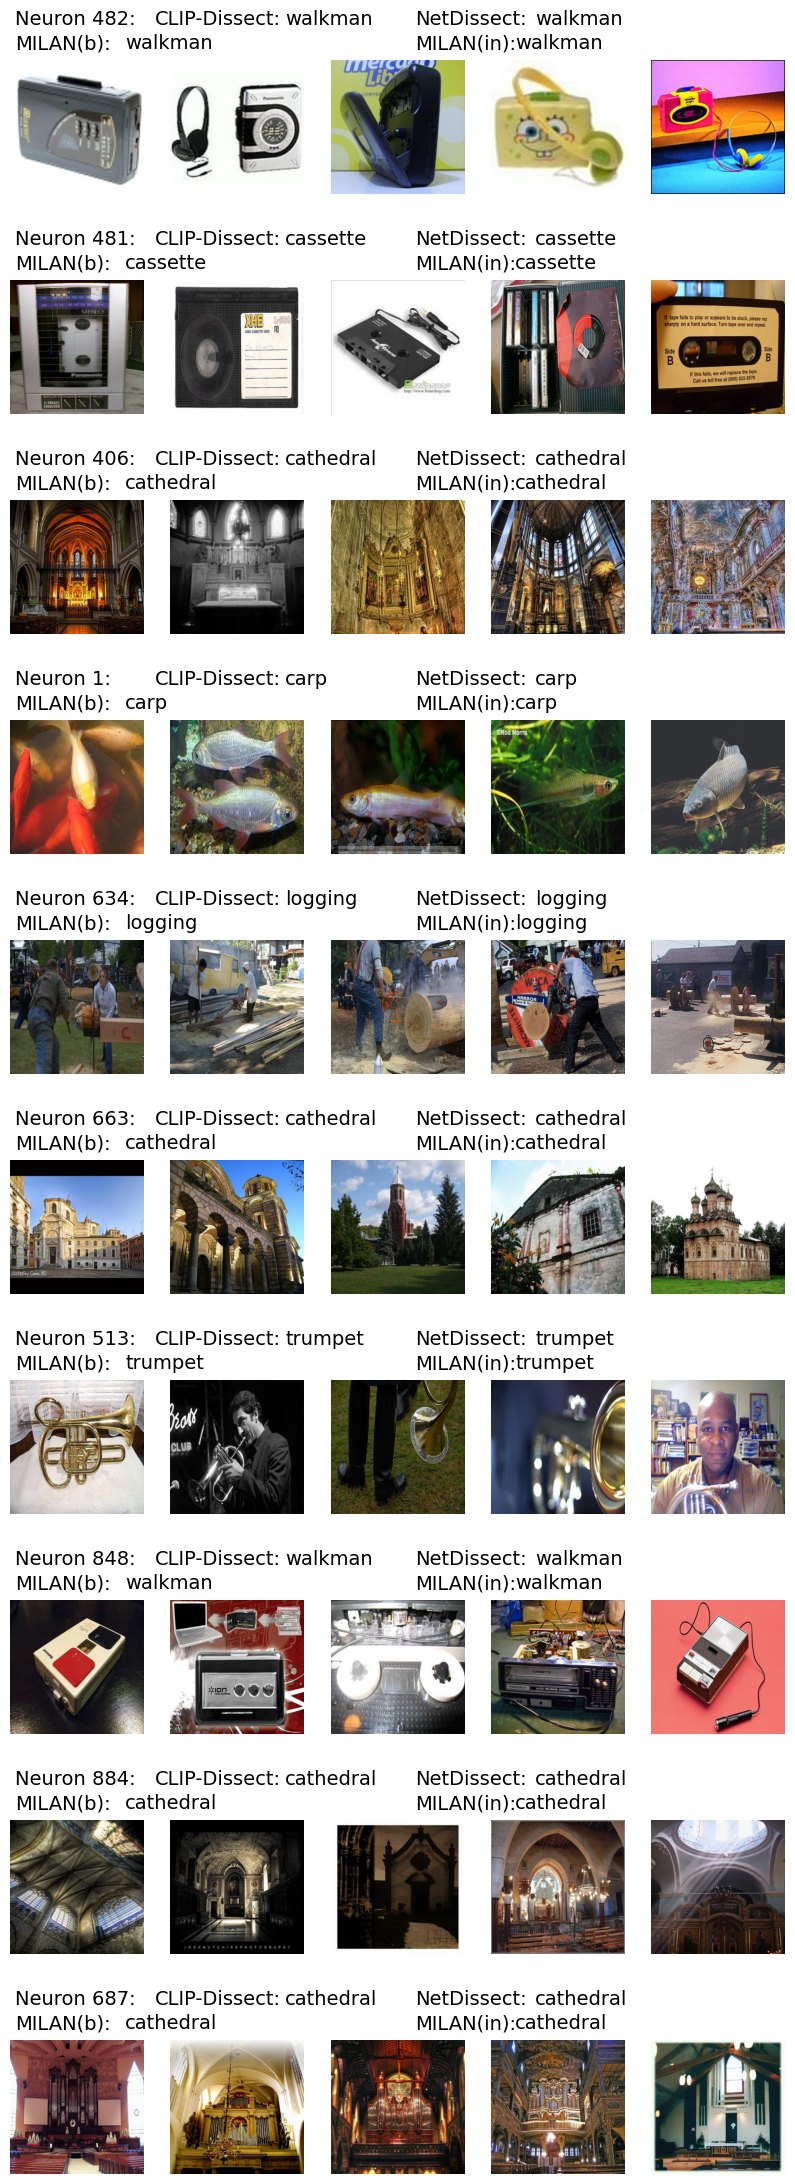

In [9]:
# Calculate which neurons to show
if type(neurons_to_display) == list:
    ids_to_check = neurons_to_display
elif neurons_to_display == "CLIP-Dissect":
    ids_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
elif neurons_to_display == "NetDissect":
    ids_to_check = torch.sort(torch.tensor(nd_ious), descending=True)[1][:10]

font_size = 14
matplotlib.rc('font', **{'size': font_size})

fig = plt.figure(figsize=[10, len(ids_to_check)*2.2])
subfigs = fig.subfigures(nrows=len(ids_to_check), ncols=1)
for j, orig_id in enumerate(ids_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)

    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4,  0.96, words[int(ids[0])], size=font_size, color=get_color("clip", j))

    if nd_labels is not None:
        subfig.text(0.53, 0.96, "NetDissect:", size=font_size)
        subfig.text(0.65, 0.96, nd_labels[orig_id], size=font_size, color=get_color("nd", j))

    if milan_base is not None:
        subfig.text(0.13, 0.85, "MILAN(b):", size=font_size)
        subfig.text(0.24, 0.85, milan_base[orig_id], size=font_size, color=get_color("milan_b", j))

    if milan_ood is not None:
        subfig.text(0.53, 0.85, "MILAN({}):".format(ood_names[target_name]), size=font_size)
        subfig.text(0.63, 0.85, milan_ood[orig_id], size=font_size, color=get_color("milan_ood", j))

    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375, 375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()